# nuPlan Dataset & Devkit — Illustrated

> Runnable, dependency-free illustrations of the concepts in [nuplan_dataset.md](nuplan_dataset.md): the SQLite log hierarchy, scenario sampling, an open-loop vs. closed-loop rollout (why error compounds), and the gated closed-loop score formula.

No `nuplan-devkit` or GPU required — everything here is `numpy` + `matplotlib` mocking the real APIs, so it runs in the shared core environment. The point is to make the *structure* of nuPlan concrete.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

rng = np.random.default_rng(0)
print('setup ok')

setup ok


## 1. The SQLite log hierarchy

Each nuPlan log is one `.db` file. Rather than download one, we build a tiny in-memory SQLite database with the same *shape* as the real tables (`lidar_pc`, `ego_pose`, `lidar_box`, `scenario_tag`, ...) and query it the way the devkit does. This shows why the format scales: it is just SQL over a compact relational schema.

In [2]:
con = sqlite3.connect(':memory:')
cur = con.cursor()
cur.executescript('''
CREATE TABLE ego_pose      (token INTEGER PRIMARY KEY, timestamp INTEGER, x REAL, y REAL, heading REAL);
CREATE TABLE lidar_pc      (token INTEGER PRIMARY KEY, timestamp INTEGER, ego_token INTEGER);
CREATE TABLE track         (token INTEGER PRIMARY KEY, category TEXT);
CREATE TABLE lidar_box     (token INTEGER PRIMARY KEY, lidar_pc_token INTEGER, track_token INTEGER, x REAL, y REAL);
CREATE TABLE scenario_tag  (token INTEGER PRIMARY KEY, lidar_pc_token INTEGER, type TEXT);
''')

# Populate ~200 keyframes of ego driving forward with a gentle left turn.
N = 200
t0 = 1_600_000_000_000_000  # microseconds, like real nuPlan timestamps
s = np.linspace(0, 60, N)
xs = s
ys = 4.0 * (1 - np.cos(s / 40.0))
hd = np.gradient(ys, xs)
for i in range(N):
    cur.execute('INSERT INTO ego_pose VALUES (?,?,?,?,?)', (i, t0 + i*100_000, xs[i], ys[i], hd[i]))
    cur.execute('INSERT INTO lidar_pc VALUES (?,?,?)', (i, t0 + i*100_000, i))

# A few tracked agents, each with boxes across frames.
cats = ['vehicle', 'vehicle', 'pedestrian', 'bicycle']
for tk, cat in enumerate(cats):
    cur.execute('INSERT INTO track VALUES (?,?)', (tk, cat))
box_tok = 0
for i in range(N):
    for tk in range(len(cats)):
        cur.execute('INSERT INTO lidar_box VALUES (?,?,?,?,?)',
                    (box_tok, i, tk, xs[i] + 8 + 5*tk, ys[i] + (-3 + 2*tk)))
        box_tok += 1

# Scenario tags fire on certain frames.
for i in range(N):
    if 40 <= i < 120:
        cur.execute('INSERT INTO scenario_tag VALUES (?,?,?)', (i, i, 'starting_left_turn'))
    if i >= 150:
        cur.execute('INSERT INTO scenario_tag VALUES (?,?,?)', (1000+i, i, 'high_magnitude_speed'))
con.commit()
print('rows:', {t: con.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
               for t in ['ego_pose','lidar_pc','lidar_box','scenario_tag']})

rows: {'ego_pose': 200, 'lidar_pc': 200, 'lidar_box': 800, 'scenario_tag': 130}


In [3]:
# Query it the way the devkit does: 'how many of each scenario type are in this log?'
for typ, n in con.execute('SELECT type, COUNT(*) FROM scenario_tag GROUP BY type ORDER BY 2 DESC'):
    print(f'{typ:24s} {n:4d} frames')

# Join boxes -> track to count agents by category (auto-labeled tracks).
print()
q = ('SELECT tr.category, COUNT(DISTINCT b.track_token) '
     'FROM lidar_box b JOIN track tr ON b.track_token = tr.token GROUP BY tr.category')
for cat, n in con.execute(q):
    print(f'{cat:12s} {n} unique tracks')

starting_left_turn         80 frames
high_magnitude_speed       50 frames

bicycle      1 unique tracks
pedestrian   1 unique tracks
vehicle      2 unique tracks


## 2. Scenarios and the ScenarioFilter

The benchmark's unit is a **Scenario**: a short slice of a log anchored at a keyframe. A `ScenarioFilter` selects slices by *type* and subsamples a fixed count. Below we extract `starting_left_turn` scenarios and plot the ego path over one of them together with the surrounding agent tracks — the exact information a planner receives as context.

sampled 5 starting_left_turn scenarios; start frames = [40, 56, 72, 88, 104]


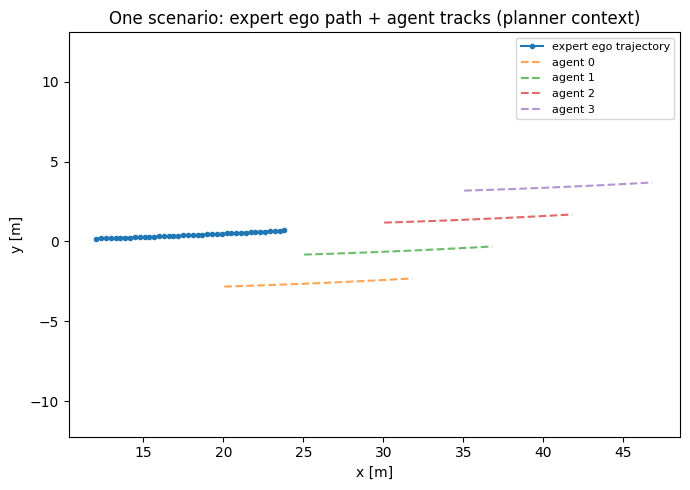

In [4]:
def get_scenarios_of_type(con, scenario_type, horizon=30, num=5):
    frames = [r[0] for r in con.execute(
        'SELECT lidar_pc_token FROM scenario_tag WHERE type=? ORDER BY lidar_pc_token', (scenario_type,))]
    # subsample evenly, like num_scenarios_per_type
    picks = frames[:: max(1, len(frames)//num)][:num]
    scenarios = []
    for f0 in picks:
        idx = list(range(f0, min(f0 + horizon, 200)))
        ego = np.array([con.execute('SELECT x,y,heading FROM ego_pose WHERE token=?', (i,)).fetchone()
                        for i in idx])
        scenarios.append({'start': f0, 'ego': ego, 'iters': idx})
    return scenarios

scenarios = get_scenarios_of_type(con, 'starting_left_turn', horizon=40, num=5)
print(f'sampled {len(scenarios)} starting_left_turn scenarios; '
      f'start frames = {[s["start"] for s in scenarios]}')

sc = scenarios[0]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sc['ego'][:,0], sc['ego'][:,1], '-o', ms=3, label='expert ego trajectory')
for tk in range(4):
    ag = np.array([con.execute(
        'SELECT x,y FROM lidar_box WHERE lidar_pc_token=? AND track_token=?', (i, tk)).fetchone()
        for i in sc['iters']])
    ax.plot(ag[:,0], ag[:,1], '--', alpha=0.7, label=f'agent {tk}')
ax.set_title('One scenario: expert ego path + agent tracks (planner context)')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.axis('equal'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Why closed-loop is harder: error compounds

This is the core idea of nuPlan. We give a planner a small constant heading bias (a stand-in for any systematic model error). In **open-loop** evaluation the state is re-anchored to the ground-truth log at every step, so the error never accumulates and the metric looks great. In **closed-loop** the ego actually moves by the (biased) command, and the next observation reflects the deviation — so the same bias drifts the car ever further off the route. Same planner, wildly different outcome.

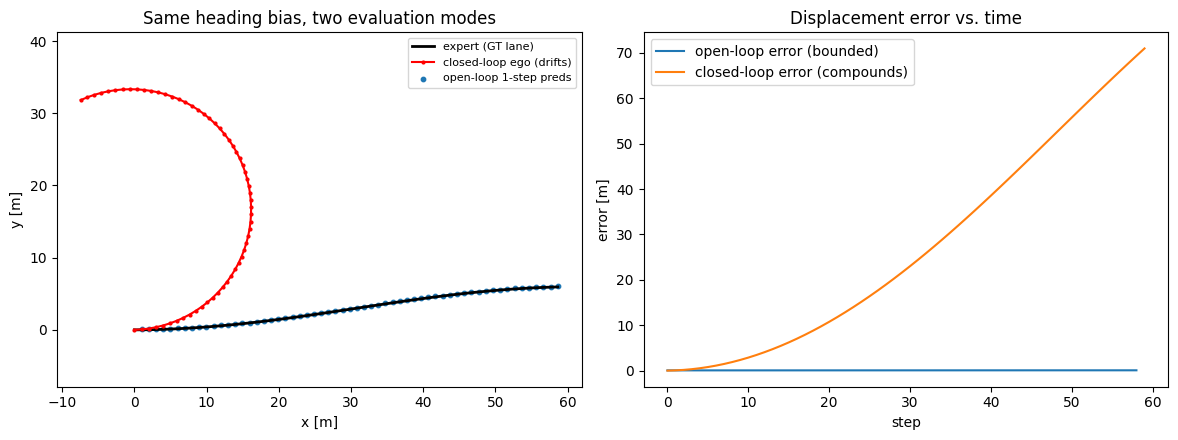

mean open-loop error : 0.060 m  (looks fine)
final closed-loop err: 70.960 m  (off the road)


In [5]:
# Ground-truth expert path (a curving lane).
T = 60
dt = 0.1
gt = np.zeros((T, 3))  # x, y, heading
v = 10.0
for t in range(1, T):
    h = 0.15 * np.sin(t * 0.05)          # the true heading profile
    gt[t,0] = gt[t-1,0] + v*dt*np.cos(h)
    gt[t,1] = gt[t-1,1] + v*dt*np.sin(h)
    gt[t,2] = h

bias = 0.06  # planner's systematic heading error [rad]

# OPEN-LOOP: at each step, planner sees GT state, we only record the 1-step prediction error.
ol = gt.copy()
ol_pred = np.zeros((T, 2))
for t in range(1, T):
    h = gt[t-1,2] + bias                 # biased command from the TRUE previous state
    ol_pred[t,0] = gt[t-1,0] + v*dt*np.cos(h)
    ol_pred[t,1] = gt[t-1,1] + v*dt*np.sin(h)
ol_err = np.linalg.norm(ol_pred[1:] - gt[1:, :2], axis=1)

# CLOSED-LOOP: the ego actually follows the biased command; next step builds on the deviated state.
cl = np.zeros((T, 3))
for t in range(1, T):
    h = cl[t-1,2] + bias
    cl[t,0] = cl[t-1,0] + v*dt*np.cos(h)
    cl[t,1] = cl[t-1,1] + v*dt*np.sin(h)
    cl[t,2] = h
cl_err = np.linalg.norm(cl[:, :2] - gt[:, :2], axis=1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(gt[:,0], gt[:,1], 'k-', lw=2, label='expert (GT lane)')
a1.plot(cl[:,0], cl[:,1], 'r-o', ms=2, label='closed-loop ego (drifts)')
a1.scatter(ol_pred[1:,0], ol_pred[1:,1], s=10, c='tab:blue', label='open-loop 1-step preds')
a1.set_title('Same heading bias, two evaluation modes'); a1.axis('equal')
a1.set_xlabel('x [m]'); a1.set_ylabel('y [m]'); a1.legend(fontsize=8)
a2.plot(ol_err, label='open-loop error (bounded)')
a2.plot(cl_err, label='closed-loop error (compounds)')
a2.set_title('Displacement error vs. time'); a2.set_xlabel('step'); a2.set_ylabel('error [m]')
a2.legend()
plt.tight_layout(); plt.show()

print(f'mean open-loop error : {ol_err.mean():.3f} m  (looks fine)')
print(f'final closed-loop err: {cl_err[-1]:.3f} m  (off the road)')

## 4. The gated closed-loop score

nuPlan's score (and NAVSIM's PDMS) is **gate metrics x weighted-average quality metrics**:

$$\text{Score} = \Big(\prod_{m \in \text{gates}} m\Big)\times\frac{5\,\text{EP} + 5\,\text{TTC} + 4\,\text{SC} + 2\,\text{C}}{5+5+4+2}$$

Gates (NC, DAC, DDC, MP) are in [0,1] and multiply — any one hitting 0 kills the score. Below we score three planners to show the hierarchy: a collision zeros an otherwise-excellent planner, while a safe-but-slow planner survives.

planner                 gate  weighted   SCORE
Aggressive learned      0.00     0.797   0.000
Safe but slow           1.00     0.810   0.810
Balanced (PDM-ish)      1.00     0.897   0.897


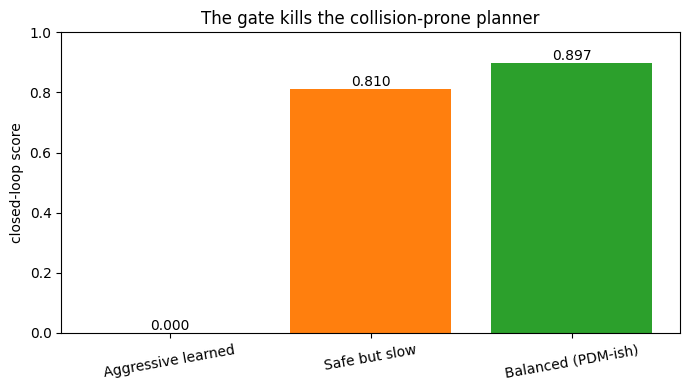

In [6]:
def closed_loop_score(nc, dac, ddc, mp, ep, ttc, sc, comfort):
    gate = nc * dac * ddc * mp
    weighted = (5*ep + 5*ttc + 4*sc + 2*comfort) / (5 + 5 + 4 + 2)
    return gate * weighted, gate, weighted

planners = {
    # name                nc  dac  ddc   mp   ep   ttc  sc  comfort
    'Aggressive learned': (0.0, 1.0, 1.0, 1.0, 0.95, 0.6, 0.9, 0.7),  # one at-fault collision -> NC=0
    'Safe but slow'     : (1.0, 1.0, 1.0, 1.0, 0.45, 0.95, 1.0, 0.98),
    'Balanced (PDM-ish)': (1.0, 1.0, 1.0, 1.0, 0.85, 0.9, 0.95, 0.9),
}
print(f"{'planner':22s}{'gate':>6}{'weighted':>10}{'SCORE':>8}")
results = {}
for name, m in planners.items():
    score, gate, weighted = closed_loop_score(*m)
    results[name] = score
    print(f'{name:22s}{gate:6.2f}{weighted:10.3f}{score:8.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
names = list(results); vals = [results[n] for n in names]
bars = ax.bar(names, vals, color=['tab:red','tab:orange','tab:green'])
ax.bar_label(bars, fmt='%.3f'); ax.set_ylim(0, 1)
ax.set_ylabel('closed-loop score'); ax.set_title('The gate kills the collision-prone planner')
plt.xticks(rotation=10); plt.tight_layout(); plt.show()

## Takeaways

- **nuPlan logs are relational.** One SQLite `.db` per drive, with tables (`ego_pose`, `lidar_box`, `scenario_tag`, ...) you query by SQL/SQLAlchemy — which is why 1500 h stays tractable.
- **Scenarios are typed.** ~75 tags let you evaluate on curated situations (left turns, high speed, ...) and report scores *per type*.
- **Closed-loop is the whole point.** A systematic error that is invisible open-loop (bounded 1-step error) compounds into off-road drift once the ego follows its own commands. Always state the mode (OL / CL-NR / CL-R).
- **The score is gated.** Safety multipliers (NC/DAC/DDC/MP) can zero the score regardless of how good the weighted quality metrics (EP/TTC/SC/Comfort) are — fix gate violations before optimising comfort.
- **This is NAVSIM's substrate.** PDMS reuses this exact gated formula on a single non-reactive rollout; learn nuPlan and NAVSIM's metric comes almost for free.

See [nuplan_dataset.md](nuplan_dataset.md) for the full devkit architecture, simulation components, and the training framework.